# Exercício sobre detecção de peças de roupa

Neste exercício, você deve criar um modelo de rede neural densamente conectada para **classificação de imagens de roupas**.

Use **otimização hiperparamétrica** para encontrar um boa arquitetura para o modelo. Crie um código que otimize o maior número de hiperparâmetros possível.

Após encontrar um bom modelo, faça o seguinte:

1. Imprima a acurácia obtida com os conjuntos de treinamento e teste.
2. Imprima a perda obtida com os conjuntos de treinamento e teste.

**OBS**.: Não se esqueça de ativar o uso de GPU.

## Importando as bibliotecas

In [2]:
import sys
import subprocess
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tenta importar o KerasTuner
try:
    import keras_tuner as kt
except ModuleNotFoundError:
    # Instala no mesmo Python usado pelo notebook
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'keras-tuner', '--upgrade'])
    import keras_tuner as kt

## Importando a base de dados Fashion MNIST

Este exercício usa a base de dados [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) que contém 70.000 imagens em tons de cinza divididas em 10 categorias (ou classes).

As imagens são arrays NumPy de dimensão $28 \times 28$ pixels. Os pixels têm valores inteiros entre 0 to 255. Os rótulos (i.e., *labels*) estão em uma array de inteiros e estão no intervalo de 0 a 9.

O número do rótulo corresponde à classe de roupa que cada imagem representa:

<table>
  <tr>
    <th>Label</th>
    <th>Classe</th>
  </tr>
  <tr>
    <td>0</td>
    <td>Camisetas/Top (T-shirt/top)</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Calça (Trouser)</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Suéter (Pullover)</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Vestidos (Dress)</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Casaco (Coat)</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandálias (Sandal)</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Camisas (Shirt)</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Tênis (Sneaker)</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bolsa (Bag)</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Botas (Ankle boot)</td>
  </tr>
</table>

Cada imagem contém um único objeto (i.e., uma peça de roupa) e, portanto, é mapeada em um só *rótulo*.

As imagens mostram **peças de roupa** com baixa resolução (28 por 28 pixels), como vemos abaixo.

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Amostras de Fashion-MNIST</a> (por Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Usaremos 60.000 imagens para treinar nossa rede neural e 10.000 imagens para avaliar quão precisamente nossa rede aprendeu a classificar as imagens.

Nós podemos acessar a base de dados *Fashion MNIST* diretamente do TensorFlow através da função `fashion_mnist.load_data()` do módulo `datasets`.

Importe e carregue a base Fashion MNIST com o código abaixo.

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

### Crie seu código abaixo.

Trial 4 Complete [00h 00m 05s]
val_accuracy: 0.828249990940094

Best val_accuracy So Far: 0.8454999923706055
Total elapsed time: 00h 00m 28s
Melhores hiperparametros encontrados:
quantidade_camadas: 3
neuronios_0: 256
ativacao_0: relu
usar_dropout_0: True
learning_rate: 0.001
taxa_dropout_0: 0.1
neuronios_1: 64
ativacao_1: relu
usar_dropout_1: False
neuronios_2: 64
ativacao_2: relu
usar_dropout_2: False
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7174 - loss: 0.8009 - val_accuracy: 0.8443 - val_loss: 0.4378
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8530 - loss: 0.4084 - val_accuracy: 0.8566 - val_loss: 0.3874
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8683 - loss: 0.3611 - val_accuracy: 0.8702 - val_loss: 0.3527
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8762 - loss: 0.3339 - val_accuracy: 0.8747 - val_loss: 0.3380
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8854 - loss: 0.

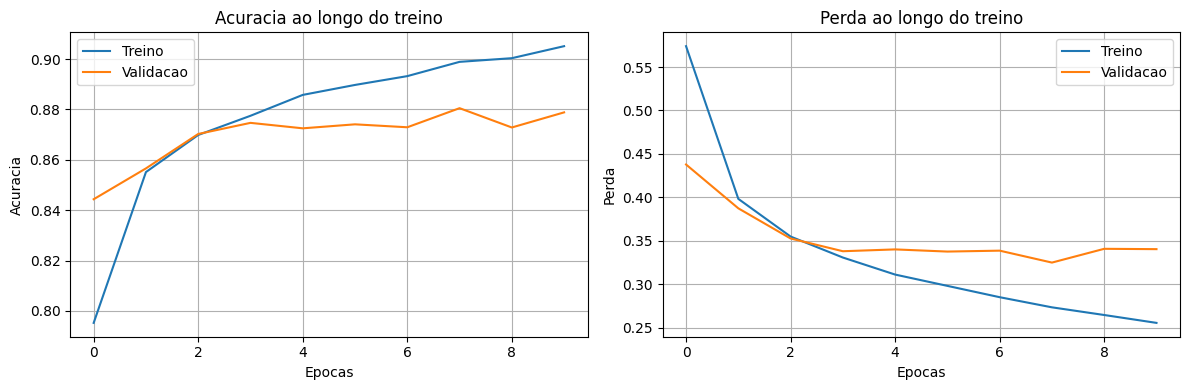

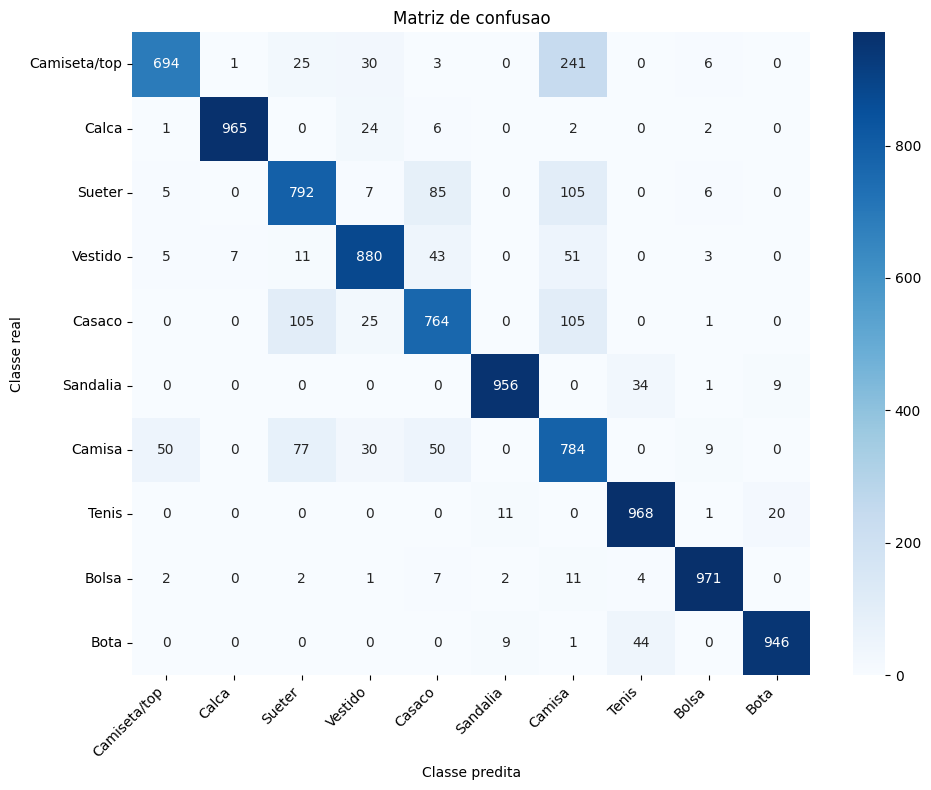

In [4]:
import tempfile

# Cria uma pasta temporaria para o KerasTuner
pasta_tuner = tempfile.mkdtemp()

# Define os nomes das classes
nomes_classes = [
    'Camiseta/top',
    'Calca',
    'Sueter',
    'Vestido',
    'Casaco',
    'Sandalia',
    'Camisa',
    'Tenis',
    'Bolsa',
    'Bota'
]

# Deixa o resultado reproduzivel
tf.keras.utils.set_random_seed(42)

# Normaliza as imagens
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Separa uma parte do treino para a busca dos hiperparametros
X_tuner = X_train[:20000]
y_tuner = y_train[:20000]

# Monta o modelo a partir dos hiperparametros
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(28, 28)))
    model.add(tf.keras.layers.Flatten())

    # Escolhe a quantidade de camadas ocultas
    quantidade_camadas = hp.Int('quantidade_camadas', min_value=1, max_value=3, step=1)

    for indice in range(quantidade_camadas):
        # Escolhe a quantidade de neuronios da camada
        neuronios = hp.Int(f'neuronios_{indice}', min_value=64, max_value=256, step=64)

        # Escolhe a funcao de ativacao da camada
        ativacao = hp.Choice(f'ativacao_{indice}', values=['relu', 'tanh'])
        model.add(tf.keras.layers.Dense(neuronios, activation=ativacao))

        # Decide se usa dropout ou nao
        usar_dropout = hp.Boolean(f'usar_dropout_{indice}')
        if usar_dropout:
            taxa_dropout = hp.Float(f'taxa_dropout_{indice}', min_value=0.1, max_value=0.4, step=0.1)
            model.add(tf.keras.layers.Dropout(taxa_dropout))

    # Cria a camada de saida
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    # Escolhe a taxa de aprendizagem
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Para o treino quando nao houver melhora
parada_antecipada = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Cria o tuner para buscar a melhor arquitetura
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=4,
    overwrite=True,
    directory=pasta_tuner,
    project_name='tuner_roupas'
)

# Busca os melhores hiperparametros
tuner.search(
    X_tuner,
    y_tuner,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    callbacks=[parada_antecipada],
    verbose=1
)

# Pega os melhores hiperparametros encontrados
melhores_hp = tuner.get_best_hyperparameters(1)[0]

print('Melhores hiperparametros encontrados:')
for nome, valor in melhores_hp.values.items():
    print(f'{nome}: {valor}')

# Monta o modelo final
modelo_final = tuner.hypermodel.build(melhores_hp)

# Treina o melhor modelo com todo o conjunto de treino
historico = modelo_final.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[parada_antecipada],
    verbose=1
)

# Mede a perda e a acuracia no treino
train_loss, train_acc = modelo_final.evaluate(X_train, y_train, verbose=0)

# Mede a perda e a acuracia no teste
test_loss, test_acc = modelo_final.evaluate(X_test, y_test, verbose=0)

print('\nResultados finais:')
print(f'Acuracia no treino: {train_acc:.4f}')
print(f'Perda no treino: {train_loss:.4f}')
print(f'Acuracia no teste: {test_acc:.4f}')
print(f'Perda no teste: {test_loss:.4f}')

# Plota a acuracia ao longo do treino
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(historico.history['accuracy'], label='Treino')
plt.plot(historico.history['val_accuracy'], label='Validacao')
plt.xlabel('Epocas')
plt.ylabel('Acuracia')
plt.title('Acuracia ao longo do treino')
plt.grid()
plt.legend()

# Plota a perda ao longo do treino
plt.subplot(1, 2, 2)
plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='Validacao')
plt.xlabel('Epocas')
plt.ylabel('Perda')
plt.title('Perda ao longo do treino')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Faz as predicoes no conjunto de teste
probabilidades = modelo_final.predict(X_test, verbose=0)
predicoes = np.argmax(probabilidades, axis=1)

# Cria a matriz de confusao
matriz = confusion_matrix(y_test, predicoes)

# Mostra a matriz de confusao
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)
plt.xlabel('Classe predita')
plt.ylabel('Classe real')
plt.title('Matriz de confusao')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
